# Regression Examples:With Bikes

- Bikes is everywhere
- The problem can be introduced in Bucaramanga
- The aplication can be introduced in UIS
- Which variable we need to predict number of bikes?



In [0]:
import matplotlib as mpl

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/My Drive/ai-uis-student/complement_notes
!pwd

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive
/content/drive/My Drive/ai-uis-student/complement_notes
/content/drive/My Drive/ai-uis-student/complement_notes


In [3]:
import pandas as pd
bikes = pd.read_csv('../data/bikes.csv')
bikes.head()

,date,temperature,humidity,windspeed,count
0,2011-01-03,2.716070,45.715346,21.414957,120.0
1,2011-01-04,2.896673,54.267219,15.136882,108.0
2,2011-01-05,4.235654,45.697702,17.034578,82.0
3,2011-01-06,3.112643,50.237349,10.091568,88.0
4,2011-01-07,2.723918,49.144928,15.738204,148.0


Text(0, 0.5, 'bikes')

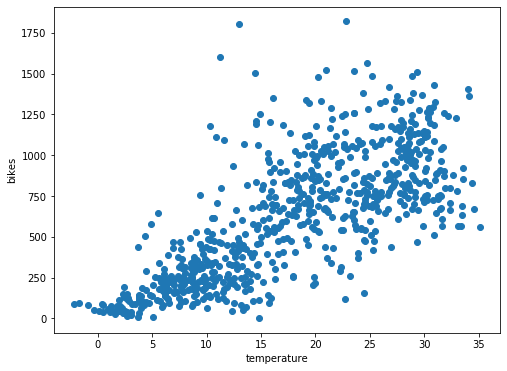

In [4]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(bikes['temperature'], bikes['count'], 'o')
plt.xlabel('temperature')
plt.ylabel('bikes')

In [0]:
X_temp = bikes.values[:,[1]] 
y_count = bikes.values[:,-1] 

In [10]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

regressor = DecisionTreeRegressor(max_depth=2)
regressorSA = DecisionTreeRegressor(max_depth=50)
regressor.fit(X_temp, y_count)
regressorSA.fit(X_temp, y_count)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=50,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')

In [11]:
regressor.predict([[3.]])

array([189.23183761])

In [12]:
regressor.predict([[20.]])

array([769.08756039])

In [13]:
print([np.linspace(-5, 40, 10)])

[array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35., 40.])]


Text(0, 0.5, 'bikes')

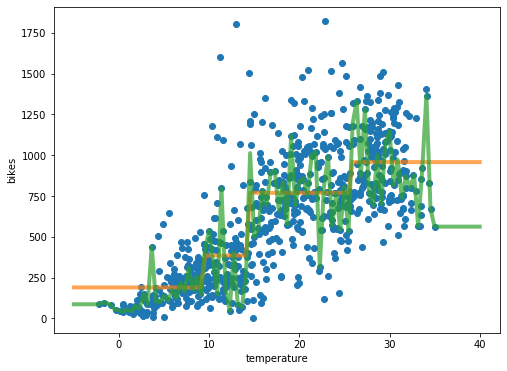

In [14]:
xx = np.array([np.linspace(-5, 40, 100)]).T

plt.figure(figsize=(8,6))
plt.plot(bikes['temperature'], bikes['count'], 'o', label='observation')
plt.plot(xx, regressor.predict(xx), linewidth=4, alpha=.7, label='prediction2')
plt.plot(xx, regressorSA.predict(xx), linewidth=4, alpha=.7, label='prediction30')
plt.xlabel('temperature')
plt.ylabel('bikes')
#plt.legend()
#plt.show()

In [15]:
print(y_count.shape)
print(X_temp.shape)

y_est =[]

for count, temperaturas  in enumerate(X_temp): 
    #print(count, y_count[count], regressor.predict(temperaturas[0]))
    y_est.append(regressor.predict(temperaturas[0]))
#y_est =

len(y_est)

(729,)
(729, 1)


ValueError: ignored

In [9]:
MSE = np.sum(np.square(y_count-np.array(y_est)))/len(y_est)
print(MSE)

ValueError: ignored

## What is the best metric to evaluate a regression performance ?

In [16]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *


print ("MSE 2 depth %.3f"% mean_squared_error(bikes['count'], regressor.predict(np.array([bikes['temperature']]).T)))
print ("MSE 30 depth %.3f"% mean_squared_error(bikes['count'], regressorSA.predict(np.array([bikes['temperature']]).T)))



MSE 2 depth 62803.790
MSE 30 depth 11534.118


In [0]:
s = cross_val_score(regressor, np.array([bikes['temperature']]).T, bikes['count'], cv=KFold(10, shuffle=True), scoring=make_scorer(mean_squared_error))
print ("MSE depth: 2 %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

s = cross_val_score(regressorSA, np.array([bikes['temperature']]).T, bikes['count'], cv=KFold(10, shuffle=True), scoring=make_scorer(mean_squared_error))
print ("MSE depth: 30 %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

MSE depth: 2 68521.044 (+/- 13030.03084)
MSE depth: 30 116528.922 (+/- 21086.46069)


In [0]:
from sklearn.tree import export_graphviz
export_graphviz(regressor, out_file='tree.dot', feature_names=['temperature'])

In [0]:
!sudo apt-get install graphviz

[sudo] password for fmartinezc: 


In [0]:
!dot -Tpng tree.dot > tree2.png # to convert the tree in a png image

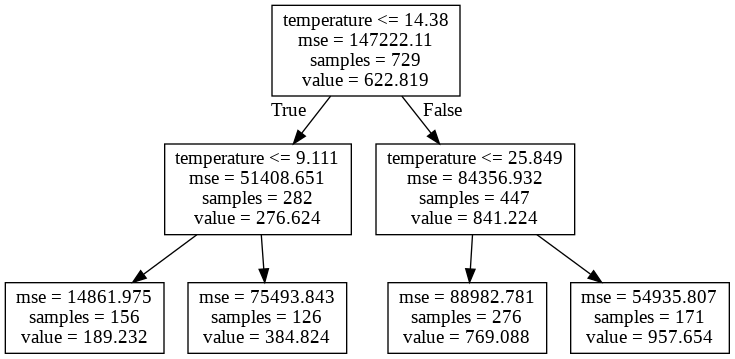

In [19]:
from IPython.display import Image
Image(filename='tree2.png') 

# Reference

[1] https://cambridgespark.com/content/tutorials/getting-started-with-regression-and-decision-trees/index.html

[2] Data: 